# Prompting LiquidAI LFM2.5 230M for JSON Classification

This Colab notebook refactors the original Granite 350M JSON classification lesson to use:

`LiquidAI/LFM2.5-230M`

The task remains the same: run small, repeatable classification workflows that return structured JSON.

## What you will learn

1. How to load LFM2.5 230M in Colab.
2. How to prompt a compact instruction model for JSON classification.
3. How to validate outputs before trusting them.
4. How to retry and repair malformed JSON.
5. How to measure classification accuracy and JSON validity.


## Practical rule

Small instruction models work best when the task is narrow, the labels are explicit, and the output schema is small.

Use this notebook for:

- sentiment classification
- support ticket routing
- email triage
- lightweight routing tasks
- structured JSON practice

Avoid asking the 230M model for long reasoning, complex multi-step planning, or open-ended creative writing in the same prompt. Keep each classification task compact.


## 1. Runtime setup

In Colab, choose:

`Runtime` → `Change runtime type` → `CPU`

A GPU can be faster, but this notebook is designed to run on CPU for portability. The model is compact enough for basic practice on standard Colab.

The native `LiquidAI/LFM2.5-230M` checkpoint uses `transformers`. If you prefer `llama.cpp`, use the separate GGUF repo instead: `LiquidAI/LFM2.5-230M-GGUF`.


In [ ]:
# Install minimal dependencies.
# LFM2.5-230M is a recent model, so use a recent Transformers version.
!pip -q install --upgrade "transformers>=5.0.0" accelerate huggingface_hub jsonschema pandas tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 765.1/765.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


## 2. Select the model

This revision uses the native Hugging Face model:

`LiquidAI/LFM2.5-230M`

The original notebook used a GGUF model through `llama-cpp-python`. This version uses `AutoTokenizer` and `AutoModelForCausalLM` because the requested model ID is the native checkpoint rather than the GGUF export.


In [ ]:
MODEL_ID = "ibm-granite/granite-4.0-h-350m"

print("Model ID:", MODEL_ID)


Model ID: ibm-granite/granite-4.0-h-350m


## 3. Load the model with conservative inference settings

For classification, prefer deterministic settings:

- `do_sample=False`
- short prompts
- small `max_new_tokens`
- explicit labels
- explicit JSON schema
- validation after generation

This cell loads the model and tokenizer. On CPU, it uses `float32` for broad compatibility. On GPU, it uses `bfloat16`.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32

print("Detected device:", device)
print("Using dtype:", dtype)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# Keep the loading code compatible across Transformers versions.
try:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        dtype=dtype,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
except TypeError:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=dtype,
        device_map="auto",
        low_cpu_mem_usage=True,
    )

model.eval()

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Model loaded.")
print("Model device:", next(model.parameters()).device)


Detected device: cpu
Using dtype: torch.float32


config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/17.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.15M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/681M [00:00<?, ?B/s]

[transformers] The fast path is not available because one of `(selective_state_update, causal_conv1d_fn, causal_conv1d_update)` is None. Falling back to the naive implementation. To install follow https://github.com/state-spaces/mamba/#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/370 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded.
Model device: cpu


## 4. Core utilities: generation, extraction, validation, and retry

Treat model output as untrusted text:

1. Generate text.
2. Print raw text when debugging.
3. Extract JSON only if JSON exists.
4. Validate the parsed object against a schema.
5. Coerce simple bare-label outputs when safe.
6. Retry with a repair prompt when needed.

The helper functions below are reusable across all classification tasks.


In [ ]:
import json
import re
import time
from typing import Any, Optional
from jsonschema import validate, ValidationError

DEFAULT_SYSTEM_PROMPT = """
You are a strict JSON classification function.
Return one valid JSON object only.
No markdown.
No explanation.
""".strip()


def make_chat_inputs(user_prompt: str, system_prompt: str = DEFAULT_SYSTEM_PROMPT) -> dict:
    """Create tokenized chat inputs using the model chat template when available."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    try:
        inputs = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        )
    except TypeError:
        rendered = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=False,
        )
        inputs = tokenizer(rendered, return_tensors="pt")

    return {key: value.to(model.device) for key, value in inputs.items()}


def generate_text(
    prompt: str,
    max_new_tokens: int = 80,
    debug: bool = False,
    return_metrics: bool = False,
) -> str | tuple[str, dict]:
    """Run deterministic generation and return raw model text."""
    inputs = make_chat_inputs(prompt)
    input_token_count = inputs["input_ids"].shape[-1]

    start = time.perf_counter()
    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id,
        )
    elapsed = time.perf_counter() - start

    new_token_ids = output_ids[0][input_token_count:]
    raw = tokenizer.decode(new_token_ids, skip_special_tokens=True).strip()

    metrics = {
        "input_tokens": int(input_token_count),
        "output_tokens": int(new_token_ids.shape[-1]),
        "latency_seconds": round(elapsed, 4),
        "tokens_per_second": round(float(new_token_ids.shape[-1]) / elapsed, 2) if elapsed > 0 else None,
    }

    if debug:
        print("RAW MODEL OUTPUT:")
        print(repr(raw))
        print("GENERATION METRICS:")
        print(metrics)

    if return_metrics:
        return raw, metrics
    return raw


def extract_first_json_object(text: str) -> str:
    """Extract the first complete JSON object using brace counting."""
    if not text or not text.strip():
        raise ValueError("Empty model output")

    start = text.find("{")
    if start == -1:
        raise ValueError(f"No JSON object found in output: {text!r}")

    depth = 0
    in_string = False
    escape = False

    for i in range(start, len(text)):
        ch = text[i]

        if in_string:
            if escape:
                escape = False
            elif ch == "\\":
                escape = True
            elif ch == '"':
                in_string = False
        else:
            if ch == '"':
                in_string = True
            elif ch == "{":
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    return text[start:i + 1]

    raise ValueError(f"Started JSON object but did not find closing brace: {text!r}")


def enum_values_for_field(schema: dict, field: str) -> list[str]:
    return schema["properties"][field]["enum"]


def coerce_bare_enum_output(raw_text: str, schema: dict, field: str) -> Optional[dict]:
    """Convert a bare output like 'positive' into {'label':'positive'} when safe."""
    allowed = enum_values_for_field(schema, field)
    cleaned = raw_text.strip().lower()
    cleaned = cleaned.replace("```json", "").replace("```", "").strip()
    cleaned = cleaned.strip(" .,:;!?'\"`\\n\\t")

    if cleaned in allowed:
        return {field: cleaned}

    hits = []
    for value in allowed:
        if re.search(rf"\\b{re.escape(value)}\\b", cleaned):
            hits.append(value)

    if len(hits) == 1:
        return {field: hits[0]}

    return None


def normalize_boolean_strings(data: dict, schema: dict) -> dict:
    """Convert 'true' and 'false' strings to booleans for fields declared as boolean."""
    data = dict(data)
    for field, spec in schema.get("properties", {}).items():
        if spec.get("type") == "boolean" and isinstance(data.get(field), str):
            lowered = data[field].strip().lower()
            if lowered == "true":
                data[field] = True
            elif lowered == "false":
                data[field] = False
    return data


def parse_and_validate(
    raw_text: str,
    schema: dict,
    single_enum_field: Optional[str] = None,
    allow_bare_enum: bool = True,
) -> dict:
    """Parse model output into JSON and validate it."""
    try:
        json_text = extract_first_json_object(raw_text)
        data = json.loads(json_text)
        data = normalize_boolean_strings(data, schema)
        validate(instance=data, schema=schema)
        return data
    except Exception as json_error:
        if allow_bare_enum and single_enum_field:
            coerced = coerce_bare_enum_output(raw_text, schema, single_enum_field)
            if coerced is not None:
                validate(instance=coerced, schema=schema)
                return coerced
        raise json_error


def schema_hint(schema: dict) -> str:
    """Create a compact schema hint for repair prompts."""
    return json.dumps(schema.get("properties", {}), ensure_ascii=False)


def classify_with_repair(
    text: str,
    prompt_builder,
    schema: dict,
    max_new_tokens: int = 80,
    single_enum_field: Optional[str] = None,
    retries: int = 2,
    debug: bool = False,
    return_trace: bool = False,
) -> dict:
    """Classify text, validate output, and retry with a repair prompt if needed."""
    raw_outputs = []
    metrics_list = []
    prompt = prompt_builder(text)

    for attempt in range(retries + 1):
        raw, metrics = generate_text(
            prompt,
            max_new_tokens=max_new_tokens,
            debug=debug,
            return_metrics=True,
        )
        raw_outputs.append(raw)
        metrics_list.append(metrics)

        try:
            parsed = parse_and_validate(
                raw,
                schema,
                single_enum_field=single_enum_field,
                allow_bare_enum=True,
            )
            if return_trace:
                return {
                    "parsed": parsed,
                    "raw_outputs": raw_outputs,
                    "metrics": metrics_list,
                    "attempts": attempt + 1,
                }
            return parsed
        except Exception as error:
            if debug:
                print(f"Attempt {attempt + 1} failed: {type(error).__name__}: {error}")

            prompt = f"""
Repair this classification output.

Return one valid JSON object only.
No markdown.
No explanation.

Input text:
{text!r}

Previous invalid model output:
{raw!r}

Required JSON properties:
{schema_hint(schema)}

Return the corrected JSON now.
JSON:
""".strip()

    raise ValueError(
        "Could not produce valid JSON after retries. "
        f"Raw outputs were: {raw_outputs!r}"
    )


## 5. Sentiment classification

This prompt uses examples and ends with `JSON:`. That final cue gives the model a clear place to continue.

The safe wrapper retries and then falls back to a small keyword heuristic only so beginner tutorial cells keep running. For real evaluation, inspect the validation report rather than hiding failures.


In [ ]:
SENTIMENT_SCHEMA = {
    "type": "object",
    "properties": {
        "label": {"type": "string", "enum": ["positive", "negative", "neutral"]},
    },
    "required": ["label"],
    "additionalProperties": False,
}


def build_sentiment_prompt(text: str) -> str:
    return f"""
You are a strict sentiment classification function.

Return only valid JSON.
No markdown.
No explanation.

Allowed labels:
- positive: praise, satisfaction, gratitude, approval, or success
- negative: complaint, frustration, rejection, failure, or dissatisfaction
- neutral: factual, unclear, mixed, or no strong sentiment

Schema:
{{"label":"positive|negative|neutral"}}

Examples:
Input: "The setup was simple and worked perfectly."
JSON: {{"label":"positive"}}

Input: "The login flow failed twice and wasted my time."
JSON: {{"label":"negative"}}

Input: "The ticket was opened on Tuesday."
JSON: {{"label":"neutral"}}

Input: {text!r}
JSON:
""".strip()


def heuristic_sentiment_fallback(text: str) -> dict:
    """Last-resort fallback so beginner tutorial cells keep running."""
    lower = text.lower()
    positive_words = ["good", "great", "simple", "worked", "perfect", "perfectly", "thanks", "thank", "love", "helpful", "easy"]
    negative_words = ["bad", "broken", "failed", "fail", "error", "wasted", "angry", "refund", "ignored", "crash", "problem"]

    pos = sum(word in lower for word in positive_words)
    neg = sum(word in lower for word in negative_words)

    if pos > neg:
        return {"label": "positive"}
    if neg > pos:
        return {"label": "negative"}
    return {"label": "neutral"}


def classify_sentiment(text: str, debug: bool = False) -> dict:
    return classify_with_repair(
        text=text,
        prompt_builder=build_sentiment_prompt,
        schema=SENTIMENT_SCHEMA,
        max_new_tokens=60,
        single_enum_field="label",
        retries=2,
        debug=debug,
    )


def classify_sentiment_safe(text: str, debug: bool = False) -> dict:
    try:
        return classify_sentiment(text, debug=debug)
    except Exception as error:
        if debug:
            print("Model classification failed after retries. Using tutorial fallback.")
            print(type(error).__name__, error)
        return heuristic_sentiment_fallback(text)


print(classify_sentiment_safe("The setup was simple and the output worked perfectly.", debug=True))


RAW MODEL OUTPUT:
'{"label":"neutral"}'
GENERATION METRICS:
{'input_tokens': 181, 'output_tokens': 6, 'latency_seconds': 58.2331, 'tokens_per_second': 0.1}
{'label': 'neutral'}


## 6. Practice cell: sentiment classification

Edit the examples and rerun the cell.

Notice that each item gets only one label. Small models perform better when labels are mutually exclusive.


In [ ]:
examples = [
    "The product arrived early and works exactly as expected.",
    "I have not received my refund and support has ignored me twice.",
    "The ticket was created on Tuesday and assigned to the billing queue.",
    "The app is useful, but the latest update made the login screen slower.",
]

for text in examples:
    print(text)
    print(classify_sentiment_safe(text, debug=False))
    print()


The product arrived early and works exactly as expected.
{'label': 'positive'}

I have not received my refund and support has ignored me twice.
{'label': 'negative'}

The ticket was created on Tuesday and assigned to the billing queue.
{'label': 'neutral'}

The app is useful, but the latest update made the login screen slower.
{'label': 'negative'}



## 7. Enterprise ticket routing

Classification is most useful when labels map to actions.

For ticket routing, keep the labels small and concrete:

- `billing`
- `technical_support`
- `account_access`
- `sales`
- `other`

The output includes two fields:

- `category`: one routing label
- `urgent`: boolean

This is harder than sentiment because the model must produce two fields.


In [ ]:
TICKET_SCHEMA = {
    "type": "object",
    "properties": {
        "category": {
            "type": "string",
            "enum": ["billing", "technical_support", "account_access", "sales", "other"],
        },
        "urgent": {"type": "boolean"},
    },
    "required": ["category", "urgent"],
    "additionalProperties": False,
}


def build_ticket_prompt(text: str) -> str:
    return f"""
You are a strict support ticket routing function.

Return only valid JSON.
No markdown.
No explanation.

Choose exactly one category:
- billing: invoices, payment, refund, charge, subscription price
- technical_support: bug, error, crash, broken feature, setup problem
- account_access: login, password, locked account, MFA, permissions
- sales: pricing question before buying, demo request, plan comparison
- other: anything else

Urgent is true only when the user says production is blocked, service is down, all users are affected, or there is a severe operational outage.

Schema:
{{"category":"billing|technical_support|account_access|sales|other","urgent":true|false}}

Examples:
Ticket: "I was charged twice."
JSON: {{"category":"billing","urgent":false}}

Ticket: "The API is down in production."
JSON: {{"category":"technical_support","urgent":true}}

Ticket: "I cannot log in after enabling MFA."
JSON: {{"category":"account_access","urgent":false}}

Ticket: "Can I schedule a demo for my team?"
JSON: {{"category":"sales","urgent":false}}

Ticket: "Please rename my workspace."
JSON: {{"category":"other","urgent":false}}

Ticket: {text!r}
JSON:
""".strip()


def classify_ticket(text: str, debug: bool = False) -> dict:
    return classify_with_repair(
        text=text,
        prompt_builder=build_ticket_prompt,
        schema=TICKET_SCHEMA,
        max_new_tokens=80,
        single_enum_field=None,
        retries=2,
        debug=debug,
    )


practice_tickets = [
    "I was charged twice this month and need a refund.",
    "We cannot log in after enabling MFA. Production deploy is blocked.",
    "Can someone explain the difference between the starter and pro plans?",
    "The dashboard crashes whenever I upload a CSV file.",
    "Please update the company name on our account profile.",
]

for ticket in practice_tickets:
    print(ticket)
    try:
        print(classify_ticket(ticket))
    except Exception as error:
        print("Could not classify as valid JSON:", type(error).__name__, error)
    print()


I was charged twice this month and need a refund.
{'category': 'billing', 'urgent': True}

We cannot log in after enabling MFA. Production deploy is blocked.
{'category': 'technical_support', 'urgent': True}

Can someone explain the difference between the starter and pro plans?
{'category': 'technical_support', 'urgent': True}

The dashboard crashes whenever I upload a CSV file.
{'category': 'technical_support', 'urgent': True}

Please update the company name on our account profile.
{'category': 'other', 'urgent': False}



## 8. Practice cell: add your own ticket examples

Add five examples that are hard but realistic.

Good practice examples include:

- mixed billing and technical issues
- vague customer language
- urgent language that is emotional but not operationally urgent
- short one-sentence tickets
- long tickets with irrelevant details


In [ ]:
my_tickets = [
    "I need help changing my plan before renewal tomorrow.",
    "The API returns a 500 error for every request in our production app.",
    "I forgot my password and no longer have access to my authenticator app.",
    "Your product looks interesting. Do you offer a demo for enterprise teams?",
    "This is annoying and I want someone to call me back.",
]

for ticket in my_tickets:
    print(ticket)
    try:
        print(classify_ticket(ticket))
    except Exception as error:
        print("Could not classify as valid JSON:", type(error).__name__, error)
    print()


I need help changing my plan before renewal tomorrow.
{'category': 'sales', 'urgent': False}

The API returns a 500 error for every request in our production app.
{'category': 'technical_support', 'urgent': True}

I forgot my password and no longer have access to my authenticator app.
{'category': 'account_access', 'urgent': True}

Your product looks interesting. Do you offer a demo for enterprise teams?
{'category': 'sales', 'urgent': False}

This is annoying and I want someone to call me back.
{'category': 'billing', 'urgent': False}



## 9. Batch evaluation with expected labels

Prompting is engineering. Measure it.

This cell compares model outputs to expected labels and reports simple accuracy. Rows that fail JSON validation are marked as invalid instead of stopping the notebook.


In [ ]:
import pandas as pd

labeled_tickets = [
    {
        "text": "My invoice is wrong and the tax amount looks too high.",
        "expected_category": "billing",
        "expected_urgent": False,
    },
    {
        "text": "The app is down for all users and our support queue is exploding.",
        "expected_category": "technical_support",
        "expected_urgent": True,
    },
    {
        "text": "I cannot reset my password because the email never arrives.",
        "expected_category": "account_access",
        "expected_urgent": False,
    },
    {
        "text": "Do you have annual pricing for a 50-seat team?",
        "expected_category": "sales",
        "expected_urgent": False,
    },
    {
        "text": "Please delete the duplicate workspace named test-company-old.",
        "expected_category": "other",
        "expected_urgent": False,
    },
]

rows = []

for item in labeled_tickets:
    try:
        trace = classify_with_repair(
            text=item["text"],
            prompt_builder=build_ticket_prompt,
            schema=TICKET_SCHEMA,
            max_new_tokens=80,
            retries=2,
            debug=False,
            return_trace=True,
        )
        prediction = trace["parsed"]
        final_metrics = trace["metrics"][-1]

        rows.append({
            **item,
            "valid_json": True,
            "predicted_category": prediction["category"],
            "predicted_urgent": prediction["urgent"],
            "category_correct": prediction["category"] == item["expected_category"],
            "urgent_correct": prediction["urgent"] == item["expected_urgent"],
            "attempts": trace["attempts"],
            "latency_seconds": final_metrics["latency_seconds"],
            "output_tokens": final_metrics["output_tokens"],
            "tokens_per_second": final_metrics["tokens_per_second"],
            "error": "",
        })
    except Exception as error:
        rows.append({
            **item,
            "valid_json": False,
            "predicted_category": None,
            "predicted_urgent": None,
            "category_correct": False,
            "urgent_correct": False,
            "attempts": None,
            "latency_seconds": None,
            "output_tokens": None,
            "tokens_per_second": None,
            "error": f"{type(error).__name__}: {error}",
        })

df = pd.DataFrame(rows)
display(df)

print("Valid JSON rate:", df["valid_json"].mean())
print("Category accuracy:", df["category_correct"].mean())
print("Urgency accuracy:", df["urgent_correct"].mean())
print("Average latency seconds:", df["latency_seconds"].dropna().mean())
print("Average tokens per second:", df["tokens_per_second"].dropna().mean())


,text,expected_category,expected_urgent,valid_json,predicted_category,predicted_urgent,category_correct,urgent_correct,attempts,latency_seconds,output_tokens,tokens_per_second,error
0,My invoice is wrong and the tax amount looks t...,billing,False,True,billing,True,True,False,1,4.0820,22,5.39,
1,The app is down for all users and our support ...,technical_support,True,True,other,True,False,True,1,4.1252,11,2.67,
2,I cannot reset my password because the email n...,account_access,False,True,other,False,False,True,1,3.0790,11,3.57,
3,Do you have annual pricing for a 50-seat team?,sales,False,True,sales,True,True,False,2,3.0112,22,7.31,
4,Please delete the duplicate workspace named te...,other,False,True,account_access,True,False,False,2,3.0614,22,7.19,


Valid JSON rate: 1.0
Category accuracy: 0.4
Urgency accuracy: 0.4
Average latency seconds: 3.4717600000000006
Average tokens per second: 5.226


## 10. Inspecting failures

When a model output fails validation, run the same item with `debug=True`.

The raw model output tells you whether the problem is:

1. Empty output.
2. Bare label instead of JSON.
3. Extra explanation text.
4. Wrong field name.
5. Wrong label.
6. Malformed JSON.


In [ ]:
# Change this text to debug a failure.
debug_text = "The setup was simple and the output worked perfectly."
print(classify_sentiment_safe(debug_text, debug=True))


RAW MODEL OUTPUT:
'```json\n{\n  "label": "positive"\n}\n```'
GENERATION METRICS:
{'input_tokens': 199, 'output_tokens': 14, 'latency_seconds': 2.512, 'tokens_per_second': 5.57}
{'label': 'positive'}


## 11. Prompt revision exercise

When the model fails, do not immediately switch models. First improve the task design.

Try these changes:

1. Reduce the number of labels.
2. Make label definitions more different from each other.
3. Add one example per label.
4. Remove optional fields from the JSON.
5. Lower `max_new_tokens` if the model rambles.
6. Add validation and retry.

For compact models, classification prompts usually improve when they are shorter, more explicit, and less conversational.


## 12. Output-only JSON prompt template

Use this template when you create new tasks.

```text
You are a strict classification function.
Return only valid JSON.
No markdown.
No explanation.

Task:
<Classify what?>

Allowed labels:
- label_a: <clear definition>
- label_b: <clear definition>
- label_c: <clear definition>

Schema:
{"label":"label_a|label_b|label_c"}

Examples:
Input: "<example A>"
JSON: {"label":"label_a"}

Input: "<example B>"
JSON: {"label":"label_b"}

Input: "<new text>"
JSON:
```

Keep schemas small. For 230M models, one to three output fields is usually safer than a deeply nested object.


## 13. Independent practice task: email triage

This task has one field and three labels. It is a good fit for a compact instruction model.

Labels:

- `reply_needed`: a human should respond
- `archive`: informational or no action needed
- `escalate`: urgent, sensitive, legal, security, outage, or executive issue


In [ ]:
EMAIL_SCHEMA = {
    "type": "object",
    "properties": {
        "action": {"type": "string", "enum": ["reply_needed", "archive", "escalate"]},
    },
    "required": ["action"],
    "additionalProperties": False,
}


def build_email_prompt(text: str) -> str:
    return f"""
You are a strict email triage classifier.

Return only valid JSON.
No markdown.
No explanation.

Choose exactly one action:
- reply_needed: the sender asks a question, requests help, or needs a response
- archive: informational, FYI, receipt, newsletter, or no response needed
- escalate: legal issue, security issue, outage, angry VIP, executive request, or urgent risk

Schema:
{{"action":"reply_needed|archive|escalate"}}

Examples:
Email: "Can you send me the updated invoice by Friday?"
JSON: {{"action":"reply_needed"}}

Email: "Your package was delivered."
JSON: {{"action":"archive"}}

Email: "The production database is down and customers cannot log in."
JSON: {{"action":"escalate"}}

Email: {text!r}
JSON:
""".strip()


def classify_email(text: str, debug: bool = False) -> dict:
    return classify_with_repair(
        text=text,
        prompt_builder=build_email_prompt,
        schema=EMAIL_SCHEMA,
        max_new_tokens=50,
        single_enum_field="action",
        retries=2,
        debug=debug,
    )


emails = [
    "Please review the attached proposal and let me know if we can move forward.",
    "Your monthly usage report is ready.",
    "Security alert: multiple failed admin login attempts detected.",
    "Thanks for the update.",
]

for email in emails:
    print(email)
    try:
        print(classify_email(email))
    except Exception as error:
        print("Could not classify as valid JSON:", type(error).__name__, error)
    print()


Please review the attached proposal and let me know if we can move forward.
{'action': 'escalate'}

Your monthly usage report is ready.
{'action': 'escalate'}

Security alert: multiple failed admin login attempts detected.
{'action': 'escalate'}

Thanks for the update.
{'action': 'escalate'}



## 14. Optional visualization

Use this cell after the batch evaluation cell. It plots valid JSON rate, category accuracy, and urgency accuracy for the ticket evaluation set.


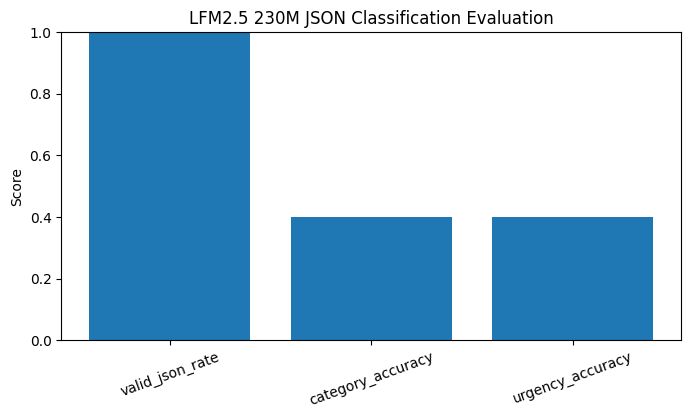

In [ ]:
import matplotlib.pyplot as plt

scores = {
    "valid_json_rate": df["valid_json"].mean(),
    "category_accuracy": df["category_correct"].mean(),
    "urgency_accuracy": df["urgent_correct"].mean(),
}

plt.figure(figsize=(8, 4))
plt.bar(scores.keys(), scores.values())
plt.ylim(0, 1)
plt.title("LFM2.5 230M JSON Classification Evaluation")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()


## 15. Next steps

Use the notebook as a base template for lightweight JSON tasks.

Recommended improvements:

1. Add 20 to 50 labeled examples for your real use case.
2. Track invalid JSON rate separately from task accuracy.
3. Keep prompt versions in a variable so you can compare them.
4. Save raw outputs so you can inspect failure modes.
5. Fine-tune or switch to a larger model only after the prompt and schema are clean.
